# 05 — Fasta Deep Dive

**Winner: C++** (~38 J) — virtually tied with C (~39 J, 1.03×), C# (~42 J), and Rust (~42 J).

Notable patterns:
- **The top 8 are tightly clustered** (38–75 J): C++, C, C#, Rust, F#, Java, Go, Swift — `fasta` is I/O and string-generation bound, and all compiled/JIT languages handle it similarly.
- **Haskell drops to 9th** (~63 J) — unlike `binary-trees`, this benchmark does not favour Haskell's GC.
- **The scripting language cliff**: Ruby, Erlang, PHP, Lua, Python, Perl all jump 10–20× above the compiled group.
- Perl finishes last (~796 J, 21× worse than C++).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BENCHMARK = 'fasta'
RUNS_CSV  = Path('../results/results_clean_runs.csv')
MEAN_CSV  = Path('../results/results_clean.csv')
FIGS_DIR  = Path('../results/figs/fasta')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

def save(name): plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight'); plt.show()
def find_col(df, kw): return next(c for c in df.columns if kw in c)
unit = lambda col: col.rsplit('-', 1)[-1].upper()

---
## 1. Load data

In [2]:
bt_runs  = pd.read_csv(RUNS_CSV)
bt_runs  = bt_runs[bt_runs['benchmark'] == BENCHMARK].copy()
bt_means = pd.read_csv(MEAN_CSV)
bt_means = bt_means[bt_means['benchmark'] == BENCHMARK].set_index('language')

COL_CPU_E  = find_col(bt_runs, 'cpu_energy')
COL_MEM_E  = find_col(bt_runs, 'memory_energy')
COL_CARBON = find_col(bt_runs, 'cpu_carbon')
COL_TIME   = find_col(bt_runs, 'phase_time')

print(f'Per-run rows: {len(bt_runs)} | Mean rows: {len(bt_means)}')
bt_means[[COL_CPU_E, COL_TIME]].sort_values(COL_CPU_E).round(3)

Per-run rows: 144 | Mean rows: 18


,cpu_energy_rapl_msr_component-package_0-j,phase_time_syscall_system-system-s
language,,
cpp,37.835,1.424
c,39.090,1.457
csharp,42.001,1.517
rust,42.263,1.563
fsharp,42.370,1.555
java,43.818,1.586
go,46.359,1.629
swift,55.090,2.605
haskell,62.521,2.396


---
## 2. Strip plot — per-run consistency

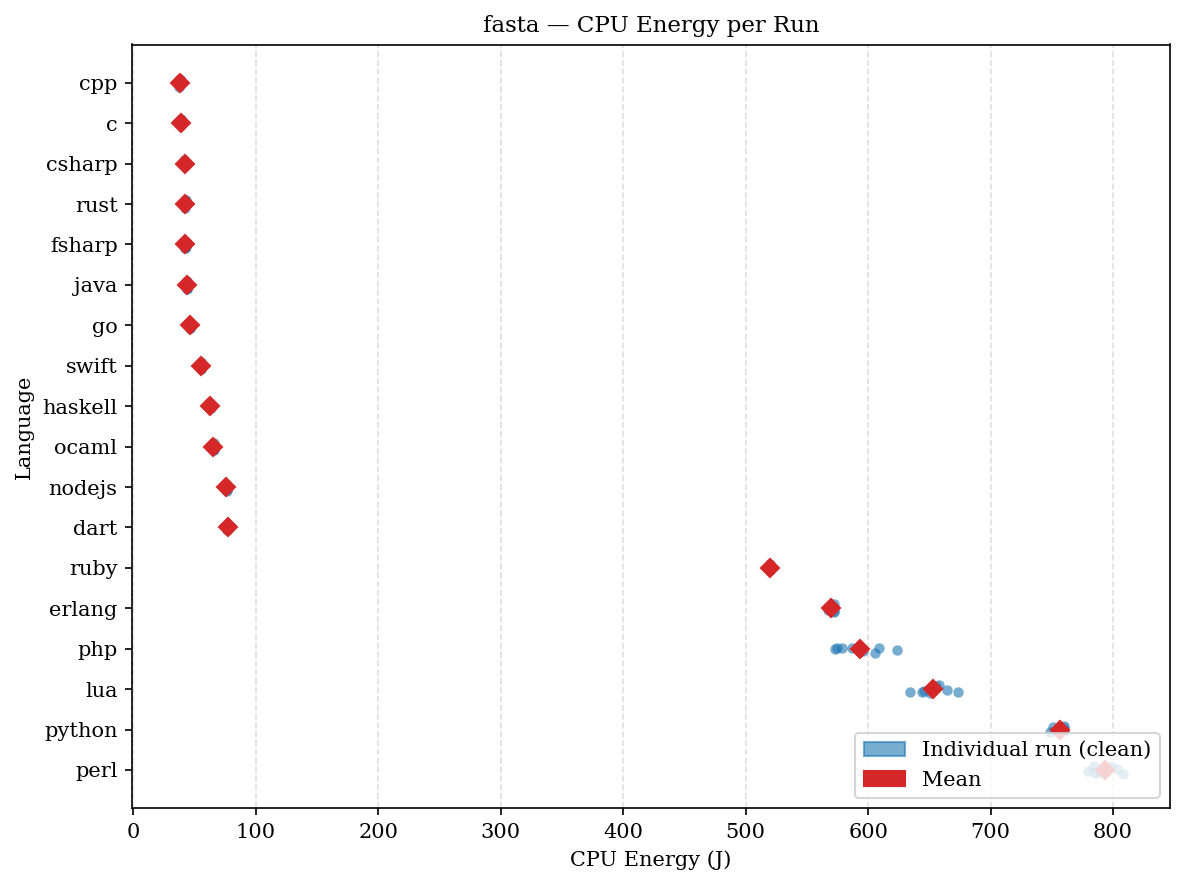

In [3]:
order = bt_means[COL_CPU_E].sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=bt_runs, x=COL_CPU_E, y='language', order=order,
              jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax)
for i, lang in enumerate(order):
    ax.plot(bt_means.loc[lang, COL_CPU_E], i, marker='D', color='#d62728', markersize=6, zorder=5)

ax.legend(handles=[
    mpatches.Patch(color='#1f77b4', alpha=0.6, label='Individual run (clean)'),
    mpatches.Patch(color='#d62728', label='Mean'),
], loc='lower right')
ax.set_xlabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_ylabel('Language')
ax.set_title(f'{BENCHMARK} — CPU Energy per Run')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('stripplot_cpu_energy')

---
## 3. Ranked bar — CPU Energy with top-cluster annotation

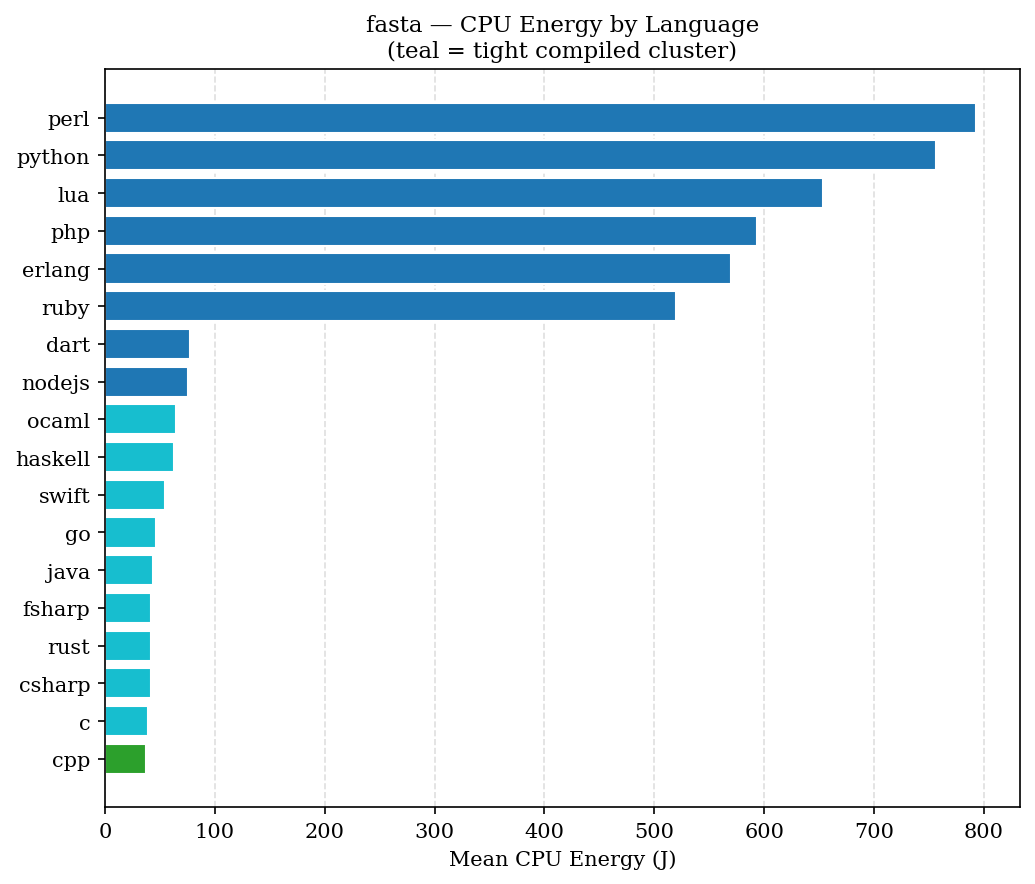

In [4]:
means = bt_means.sort_values(COL_CPU_E)
winner = means.index[0]

# Colour the tight top cluster differently to highlight the grouping
top_threshold = means.loc[winner, COL_CPU_E] * 2.0
colors = ['#2ca02c' if i == 0 else ('#17becf' if v <= top_threshold else '#1f77b4')
          for i, v in enumerate(means[COL_CPU_E])]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(means.index, means[COL_CPU_E], color=colors, edgecolor='white')

ax.set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — CPU Energy by Language\n(teal = tight compiled cluster)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('bar_cpu_energy')

---
## 4. Zoom — top 10 languages (compiled cluster detail)

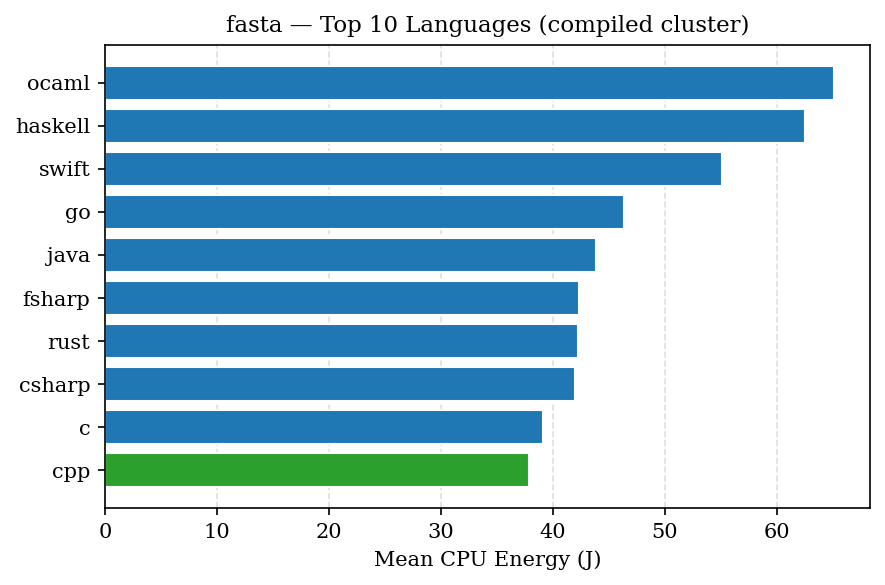

In [5]:
top10 = means.head(10)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top10.index, top10[COL_CPU_E], color='#1f77b4', edgecolor='white')
ax.barh(top10.index[:1], top10[COL_CPU_E].iloc[:1], color='#2ca02c', edgecolor='white')
ax.set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — Top 10 Languages (compiled cluster)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('bar_top10_zoom')

---
## 5. Normalised to winner

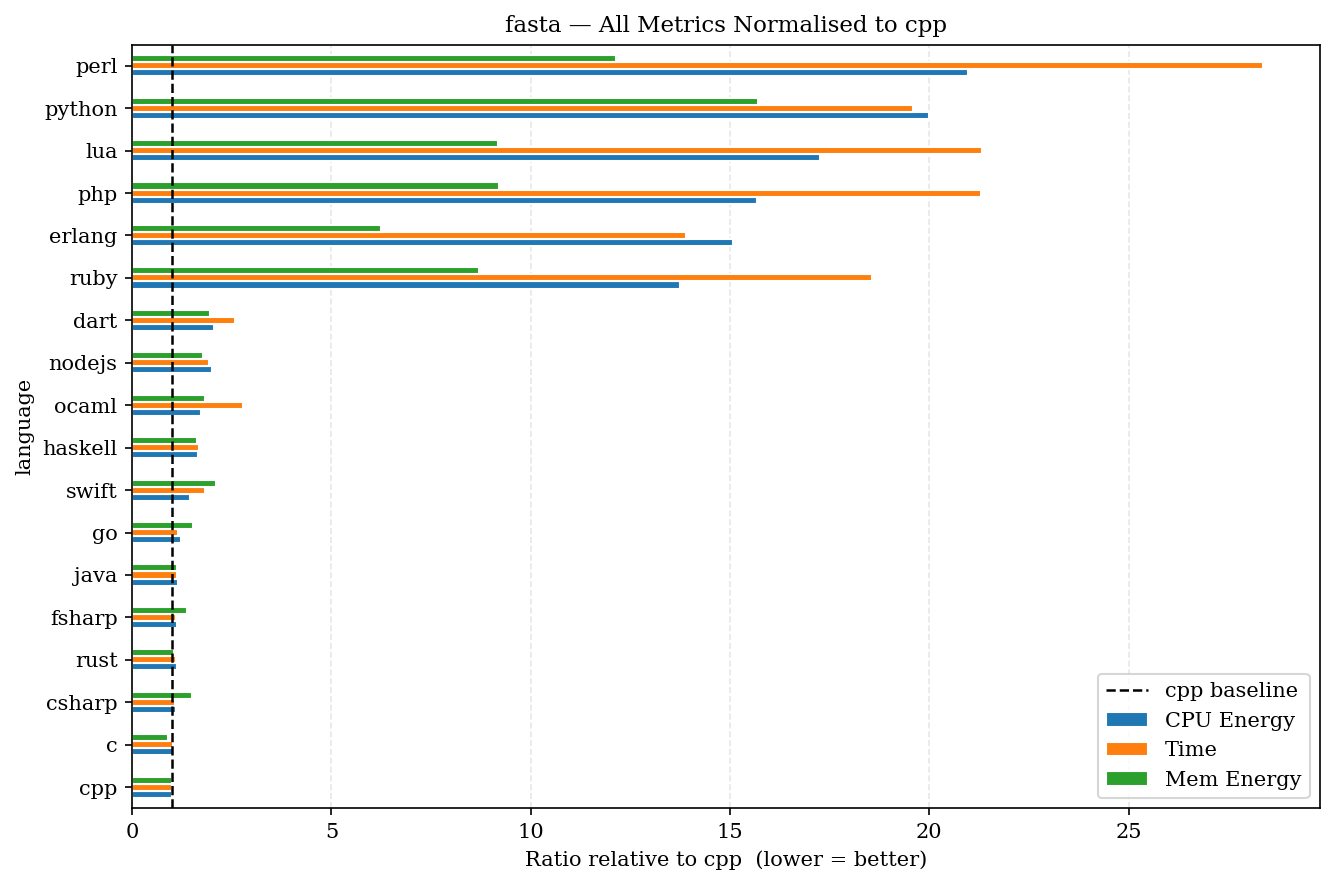

In [6]:
subset = means[[COL_CPU_E, COL_TIME, COL_MEM_E]]
ratio = subset.div(subset.loc[winner])
ratio.columns = ['CPU Energy', 'Time', 'Mem Energy']

fig, ax = plt.subplots(figsize=(9, 6))
ratio.plot(kind='barh', ax=ax, edgecolor='white')
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', label=f'{winner} baseline')
ax.set_xlabel(f'Ratio relative to {winner}  (lower = better)')
ax.set_title(f'{BENCHMARK} — All Metrics Normalised to {winner}')
ax.legend(loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save('normalised')

---
## 6. Energy vs. Time scatter

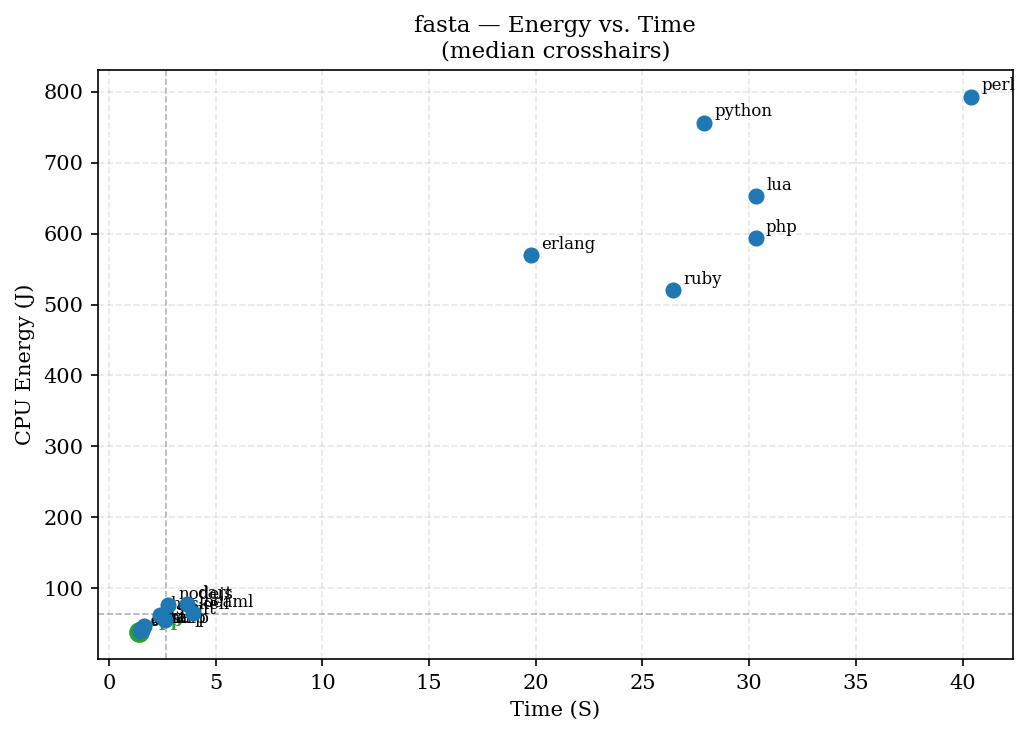

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for lang, row in means.iterrows():
    color = '#2ca02c' if lang == winner else '#1f77b4'
    ax.scatter(row[COL_TIME], row[COL_CPU_E], color=color, s=80 if lang == winner else 45, zorder=3)
    ax.annotate(lang, (row[COL_TIME], row[COL_CPU_E]),
                textcoords='offset points', xytext=(5, 3), fontsize=8,
                color='#2ca02c' if lang == winner else 'black',
                fontweight='bold' if lang == winner else 'normal')

ax.axvline(means[COL_TIME].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(means[COL_CPU_E].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel(f'Time ({unit(COL_TIME)})')
ax.set_ylabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — Energy vs. Time\n(median crosshairs)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save('scatter_energy_vs_time')

---
## 7. Summary table

In [8]:
summary = means[[COL_CPU_E, COL_TIME, COL_MEM_E, COL_CARBON]].copy()
summary.columns = [f'CPU Energy ({unit(COL_CPU_E)})', f'Time ({unit(COL_TIME)})',
                   f'Mem Energy ({unit(COL_MEM_E)})', f'CPU Carbon ({unit(COL_CARBON)})']
summary.round(4)

,CPU Energy (J),Time (S),Mem Energy (J),CPU Carbon (G)
language,,,,
cpp,37.8347,1.4236,1.0051,0.0035
c,39.0905,1.4568,0.8954,0.0036
csharp,42.0009,1.5175,1.5033,0.0039
rust,42.2634,1.5627,1.0430,0.0039
fsharp,42.3705,1.5552,1.3904,0.0039
java,43.8178,1.5856,1.1226,0.0041
go,46.3589,1.6294,1.5215,0.0043
swift,55.0897,2.6049,2.1221,0.0051
haskell,62.5206,2.3959,1.6413,0.0058
